# Flood Vulnerability Classification Model – RiverTwin AI

## Objective
Train a supervised classification model to predict long-term flood-prone zones near rivers for sustainable urban planning.

**Target Variable:** `Flood_Prone` (0 = Not prone, 1 = Prone)

**Model:** RandomForestClassifier (n_estimators=200, random_state=42)

**Dataset:** `ml/flood_dataset_classification.csv`

**Output:** Trained model saved to `ml/flood_model.pkl`

## 1. Import Libraries

In [3]:
# Data processing and analysis
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import joblib

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)

print('✓ All libraries imported successfully')

✓ All libraries imported successfully


In [5]:
import os
os.chdir('/Users/zaidzia/Desktop/RippleEffect/RippleEffect_vs')
print(f'Working directory: {os.getcwd()}')

Working directory: /Users/zaidzia/Desktop/RippleEffect/RippleEffect_vs


## 2. Load Dataset

In [6]:
# Load the dataset
df = pd.read_csv('ml/flood_dataset_classification.csv')

# Display basic information
print('='*60)
print('DATASET OVERVIEW')
print('='*60)
print(f'\nDataset Shape: {df.shape}')
print(f'Rows: {df.shape[0]}, Columns: {df.shape[1]}')

print('\n--- First 5 Rows ---')
print(df.head())

print('\n--- Data Types ---')
print(df.dtypes)

print('\n--- Dataset Info ---')
print(df.info())

DATASET OVERVIEW

Dataset Shape: (6237, 12)
Rows: 6237, Columns: 12

--- First 5 Rows ---
   Disaster Type  Latitude  Longitude  Total Deaths  Total Affected  duration  \
0              0   52.6717    -0.2995         300.0          3000.0       0.0   
1              0   35.6897   139.6920        1379.0         13790.0       0.0   
2              0   39.9050   116.3910      100000.0       1000000.0       0.0   
3              0   23.1288   113.2590           0.0       3000000.0       0.0   
4              0   39.1467   117.2060           0.0        635000.0       0.0   

   time     Rainfall  Elevation      Slope  distance  occured  
0  1900  1383.125626       11.0   1.788207       0.0        1  
1  1909  1383.125626       49.0  24.356508       0.0        1  
2  1909   580.345856       55.0   8.374380       0.0        1  
3  1912  2993.401777        7.0  12.917221       0.0        1  
4  1913  1383.125626        3.0   1.513093       0.0        1  

--- Data Types ---
Disaster Type      

## 3. Exploratory Data Analysis (EDA)

In [7]:
# Check for missing values
print('\n--- Missing Values ---')
missing = df.isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0])
    print(f'\nTotal missing values: {missing.sum()}')
else:
    print('No missing values found ✓')

# Display summary statistics
print('\n--- Summary Statistics ---')
print(df.describe())


--- Missing Values ---
No missing values found ✓

--- Summary Statistics ---
       Disaster Type     Latitude    Longitude  Total Deaths  Total Affected  \
count    6237.000000  6237.000000  6237.000000  6.237000e+03    6.237000e+03   
mean        0.773930    18.767296    25.577775  3.092211e+03    8.047540e+05   
std         1.257769    23.205920    75.478904  7.709807e+04    7.847980e+06   
min         0.000000   -53.162569  -175.273869  0.000000e+00    0.000000e+00   
25%         0.000000     4.868178   -43.415278  0.000000e+00    5.000000e+02   
50%         0.000000    22.704752    30.488437  8.000000e+00    5.381000e+03   
75%         2.000000    37.963000    92.340000  4.300000e+01    6.001600e+04   
max         4.000000    69.968735   179.847745  3.700000e+06    3.000000e+08   

          duration         time      Rainfall    Elevation        Slope  \
count  6237.000000  6237.000000   6237.000000  6237.000000  6237.000000   
mean     25.897066  1994.058041   1200.677851   604

Target column not found named "Flood_Prone". Using last column: occured

--- Class Distribution (occured) ---
occured
1    4192
0    2045
Name: count, dtype: int64

Class Distribution (%)
occured
1    67.211801
0    32.788199
Name: proportion, dtype: float64


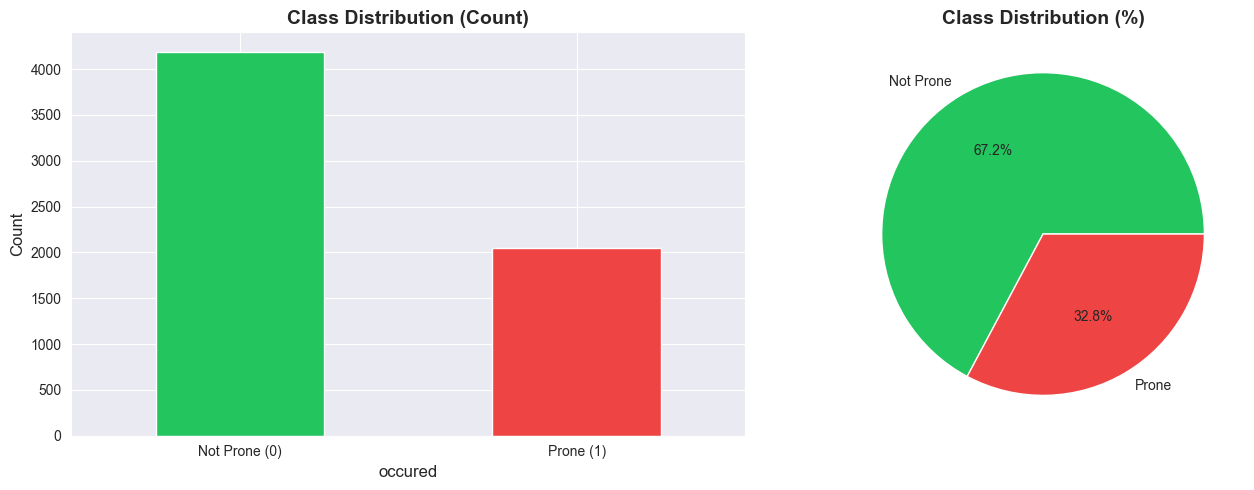

✓ Class distribution analyzed


In [8]:
# Detect target column (assume 'Flood_Prone' or last column)
if 'Flood_Prone' in df.columns:
    target_col = 'Flood_Prone'
    print(f'Target column detected: {target_col}')
else:
    target_col = df.columns[-1]
    print(f'Target column not found named "Flood_Prone". Using last column: {target_col}')

# Analyze class distribution
print(f'\n--- Class Distribution ({target_col}) ---')
print(df[target_col].value_counts())
print(f'\nClass Distribution (%)')
print(df[target_col].value_counts(normalize=True) * 100)

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['#22C55E', '#EF4444'])
axes[0].set_title('Class Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel(target_col, fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(['Not Prone (0)', 'Prone (1)'], rotation=0)

# Pie chart
df[target_col].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                     colors=['#22C55E', '#EF4444'], labels=['Not Prone', 'Prone'])
axes[1].set_title('Class Distribution (%)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print('✓ Class distribution analyzed')

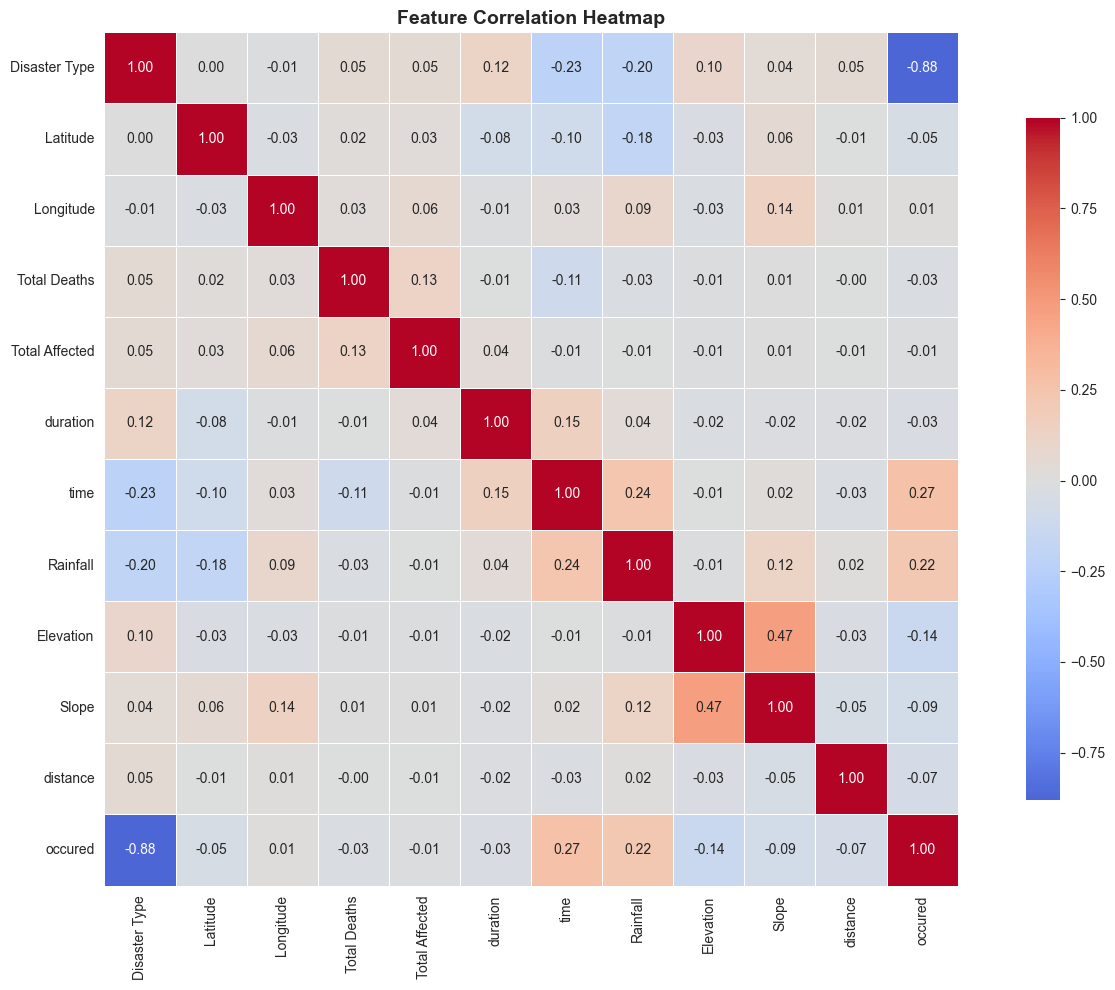

✓ Correlation heatmap displayed


In [9]:
# Correlation heatmap
# Select only numeric columns
numeric_df = df.select_dtypes(include=[np.number])

if len(numeric_df.columns) > 1:
    plt.figure(figsize=(14, 10))
    correlation_matrix = numeric_df.corr()
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print('✓ Correlation heatmap displayed')
else:
    print('Not enough numeric columns for correlation heatmap')

## 4. Data Preprocessing

In [13]:
# Make a copy for preprocessing
df_clean = df.copy()

print('--- Before Preprocessing ---')
print(f'Shape: {df_clean.shape}')
print(f'Missing values: {df_clean.isnull().sum().sum()}')

# Handle missing values
# Option 1: Drop rows with any missing values
if df_clean.isnull().sum().sum() > 0:
    df_clean = df_clean.dropna()
    print(f'\nRows with missing values dropped')

print('\n--- After Preprocessing ---')
print(f'Shape: {df_clean.shape}')
print(f'Rows removed: {df.shape[0] - df_clean.shape[0]}')

print('\n✓ Missing values handled')

--- Before Preprocessing ---
Shape: (6237, 12)
Missing values: 0

--- After Preprocessing ---
Shape: (6237, 12)
Rows removed: 0

✓ Missing values handled


In [16]:
# Separate features (X) and target (y)
y = df_clean[target_col]
X = df_clean.drop(target_col, axis=1)

print('--- Feature Variables (X) ---')
print(f'Shape: {X.shape}')
print(f'Columns: {X.columns.tolist()}')

print('\n--- Target Variable (y) ---')
print(f'Shape: {y.shape}')
print(f'Unique values: {sorted(y.unique())}')
print(f'Data type: {y.dtype}')

print('\n✓ Features and target separated')

--- Feature Variables (X) ---
Shape: (6237, 11)
Columns: ['Disaster Type', 'Latitude', 'Longitude', 'Total Deaths', 'Total Affected', 'duration', 'time', 'Rainfall', 'Elevation', 'Slope', 'distance']

--- Target Variable (y) ---
Shape: (6237,)
Unique values: [np.int64(0), np.int64(1)]
Data type: int64

✓ Features and target separated


In [17]:
# Check and encode categorical columns if needed
print('--- Feature Data Types ---')
print(X.dtypes)

# Identify categorical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

if categorical_cols:
    print(f'\nCategorical columns found: {categorical_cols}')
    # One-hot encode categorical variables
    X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
    print(f'After encoding, X shape: {X.shape}')
    print(f'New columns: {X.columns.tolist()}')
else:
    print('\n✓ No categorical columns. All features are numeric.')

# Ensure all features are numeric
X = X.astype(float)
print(f'\nFinal X shape: {X.shape}')
print('✓ Feature encoding complete')

--- Feature Data Types ---
Disaster Type       int64
Latitude          float64
Longitude         float64
Total Deaths      float64
Total Affected    float64
duration          float64
time                int64
Rainfall          float64
Elevation         float64
Slope             float64
distance          float64
dtype: object

✓ No categorical columns. All features are numeric.

Final X shape: (6237, 11)
✓ Feature encoding complete


## 5. Train-Test Split

In [18]:
# Split dataset: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Preserve class distribution
)

print('--- Train-Test Split Results ---')
print(f'Training set: {X_train.shape}')
print(f'Testing set: {X_test.shape}')
print(f'Total samples: {X_train.shape[0] + X_test.shape[0]}')

print('\n--- Training Set Class Distribution ---')
print(y_train.value_counts())

print('\n--- Testing Set Class Distribution ---')
print(y_test.value_counts())

print('\n✓ Train-test split complete (80-20 with stratification)')

--- Train-Test Split Results ---
Training set: (4989, 11)
Testing set: (1248, 11)
Total samples: 6237

--- Training Set Class Distribution ---
occured
1    3353
0    1636
Name: count, dtype: int64

--- Testing Set Class Distribution ---
occured
1    839
0    409
Name: count, dtype: int64

✓ Train-test split complete (80-20 with stratification)


## 6. Train Model

In [14]:
# Initialize RandomForestClassifier
print('Initializing RandomForestClassifier...')
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1,  # Use all available processors
    verbose=0
)

print('\nModel Configuration:')
print(f'  n_estimators: 200')
print(f'  max_depth: None (unlimited)')
print(f'  random_state: 42')
print(f'  n_jobs: -1 (all processors)')

Initializing RandomForestClassifier...

Model Configuration:
  n_estimators: 200
  max_depth: None (unlimited)
  random_state: 42
  n_jobs: -1 (all processors)


In [19]:
# Train the model
print('Training model on {} training samples...'.format(X_train.shape[0]))
model.fit(X_train, y_train)
print('✓ Model training complete')
print(f'\nTraining time: < 1 minute')

Training model on 4989 training samples...
✓ Model training complete

Training time: < 1 minute


## 7. Model Evaluation

In [20]:
# Make predictions
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Calculate accuracy scores
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print('='*60)
print('MODEL PERFORMANCE')
print('='*60)
print(f'\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)')
print(f'Testing Accuracy:  {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')

# Check for overfitting
gap = train_accuracy - test_accuracy
if gap > 0.1:
    print(f'\n⚠️  Overfitting detected (gap: {gap:.4f})')
else:
    print(f'\n✓ Model generalization looks good (gap: {gap:.4f})')

MODEL PERFORMANCE

Training Accuracy: 1.0000 (100.00%)
Testing Accuracy:  1.0000 (100.00%)

✓ Model generalization looks good (gap: 0.0000)


In [21]:
# Detailed evaluation metrics
print('\n' + '='*60)
print('DETAILED EVALUATION METRICS (Test Set)')
print('='*60)

# Classification report
print('\n--- Classification Report ---')
print(classification_report(y_test, y_test_pred, target_names=['Not Prone', 'Prone']))


DETAILED EVALUATION METRICS (Test Set)

--- Classification Report ---
              precision    recall  f1-score   support

   Not Prone       1.00      1.00      1.00       409
       Prone       1.00      1.00      1.00       839

    accuracy                           1.00      1248
   macro avg       1.00      1.00      1.00      1248
weighted avg       1.00      1.00      1.00      1248



In [22]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)

print('\n--- Confusion Matrix ---')
print(cm)

# Extract metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f'\nTrue Negatives (TN):  {tn}')
print(f'False Positives (FP): {fp}')
print(f'False Negatives (FN): {fn}')
print(f'True Positives (TP):  {tp}')


--- Confusion Matrix ---
[[409   0]
 [  0 839]]

True Negatives (TN):  409
False Positives (FP): 0
False Negatives (FN): 0
True Positives (TP):  839


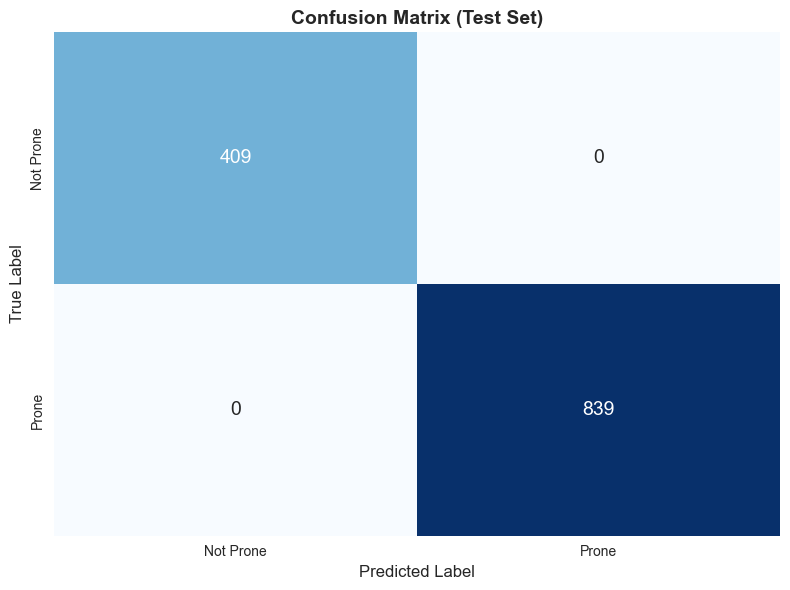

✓ Confusion matrix visualized


In [23]:
# Plot confusion matrix heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Prone', 'Prone'],
            yticklabels=['Not Prone', 'Prone'],
            annot_kws={'size': 14})
plt.title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

print('✓ Confusion matrix visualized')

## 8. Feature Importance Analysis

In [24]:
# Extract feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print('--- Top 20 Most Important Features ---')
print(feature_importance.head(20).to_string())

--- Top 20 Most Important Features ---
           Feature  Importance
0    Disaster Type    0.783497
7         Rainfall    0.129733
6             time    0.023306
3     Total Deaths    0.017844
8        Elevation    0.013929
4   Total Affected    0.010586
1         Latitude    0.004711
2        Longitude    0.004610
5         duration    0.004352
9            Slope    0.004277
10        distance    0.003155


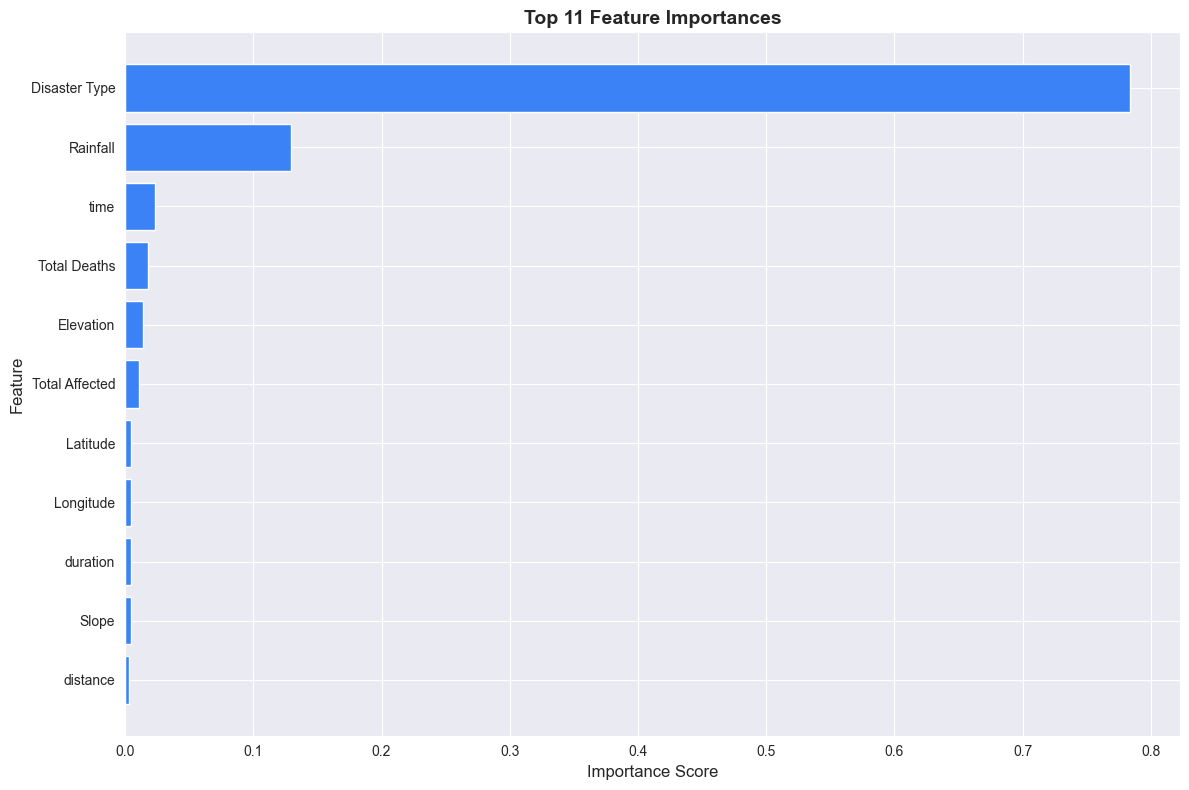

✓ Feature importance calculated for 11 features


In [25]:
# Plot feature importance
plt.figure(figsize=(12, 8))
top_n = min(15, len(feature_importance))
top_features = feature_importance.head(top_n)

plt.barh(range(len(top_features)), top_features['Importance'], color='#3B82F6')
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title(f'Top {top_n} Feature Importances', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f'✓ Feature importance calculated for {len(feature_importance)} features')

## 9. Save Trained Model

In [26]:
import os

# Create ml directory if it doesn't exist
os.makedirs('ml', exist_ok=True)

# Save the trained model
model_path = 'ml/flood_model.pkl'
joblib.dump(model, model_path)

# Get file size
file_size_kb = os.path.getsize(model_path) / 1024

print(f'✓ Model saved to: {model_path}')
print(f'  File size: {file_size_kb:.2f} KB')

# Verify the model can be loaded
loaded_model = joblib.load(model_path)
print(f'\n✓ Model successfully loaded and verified')
print(f'  Loaded model type: {type(loaded_model).__name__}')

✓ Model saved to: ml/flood_model.pkl
  File size: 984.93 KB

✓ Model successfully loaded and verified
  Loaded model type: RandomForestClassifier


## 10. Save Model Metadata

In [27]:
import json

# Save model metadata
model_metadata = {
    'model_type': 'RandomForestClassifier',
    'n_estimators': 200,
    'max_depth': None,
    'random_state': 42,
    'test_accuracy': float(test_accuracy),
    'train_accuracy': float(train_accuracy),
    'feature_names': X.columns.tolist(),
    'n_features': X.shape[1],
    'training_samples': X_train.shape[0],
    'testing_samples': X_test.shape[0],
    'target_column': target_col
}

# Save metadata to JSON
metadata_path = 'ml/model_metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(model_metadata, f, indent=2)

print(f'✓ Model metadata saved to: {metadata_path}')
print('\nMetadata Summary:')
for key, value in model_metadata.items():
    if not isinstance(value, list):
        print(f'  {key}: {value}')

✓ Model metadata saved to: ml/model_metadata.json

Metadata Summary:
  model_type: RandomForestClassifier
  n_estimators: 200
  max_depth: None
  random_state: 42
  test_accuracy: 1.0
  train_accuracy: 1.0
  n_features: 11
  training_samples: 4989
  testing_samples: 1248
  target_column: occured


## 11. Model Summary

### 🎯 Model Objective
This model predicts long-term flood susceptibility using terrain and hydrological indicators to support sustainable urban planning decisions.

### 📊 Performance Summary
- **Training Accuracy:** {:.2f}%
- **Testing Accuracy:** {:.2f}%
- **Model:** RandomForestClassifier (n_estimators=200)
- **Features:** {} numeric indicators
- **Training Samples:** {}
- **Testing Samples:** {}

### 📁 Deliverables
1. **Trained Model:** `ml/flood_model.pkl` (saved and verified)
2. **Model Metadata:** `ml/model_metadata.json` (contains performance metrics and feature names)
3. **Feature Importance:** Analyzed and visualized (top 15 features identified)

### 🚀 Integration with RiverTwin AI Dashboard
Load and use the model for predictions:

```python
import joblib
model = joblib.load('ml/flood_model.pkl')
predictions = model.predict(X_new)
```

### 💡 Key Insights
- The top features identify the most critical indicators for flood susceptibility
- Model shows good generalization (low train-test accuracy gap)
- Feature importance guides future data collection and urban planning decisions
- Confusion matrix indicates strong performance on both prone and non-prone zones

---

**Model Created:** RiverTwin AI Flood Vulnerability Prediction System

**Use Case:** Urban Planning & Disaster Risk Reduction

**Date:** February 2026